## **Exercise 2.2.1**

Write a program that accepts a matrix $A$, checks that it is symmetric (if real) and then returns the **Cholesky factor** $L$.

1. Test the program on the matrix
   $$
   A = \begin{pmatrix} 
   4 & 12 & -16 \\ 
   12 & 37 & -43 \\ 
   -16 & -43 & 98 
   \end{pmatrix}
   $$
   and check the correctness of the result. This program will be useful later on.

2. Write a solver that wraps together Cholesky factorization with **backward and forward substitutions**.

3. Calculate the Laplacian matrix $K$ and the vector $b$ using:
   * $4\pi\varepsilon_0 = 1.0$
   * $L = 1.0$
   * $N = 50$
   * Gaussian distributed charge density $\rho(x) = e^{-R(x-0.5)^2}$

   Solve the linear system for the cases $R = 100$ and $R = 10$ using the solver based on Cholesky's decomposition.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os
sys.path.append(os.path.abspath('..'))
from lib_algebra import chol_fact, BackChol


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:

plt.rcParams.update({
    "text.usetex": True,           # Attiva l'uso di LaTeX per tutto il testo
    "font.family": "serif",        # Usa un font Serif per il testo normale
    "font.serif": ["Palatino"],    # Specifica Palatino (molto simile a quello in foto)
    "axes.labelsize": 16,          # Dimensione font etichette assi
    "font.size": 14,                # Dimensione font generale
    "legend.fontsize": 14,         # Dimensione font legenda
    "xtick.labelsize": 13,         # Dimensione numeri asse x
    "ytick.labelsize": 13,         # Dimensione numeri asse y
    "figure.figsize": (8, 6),      # Dimensione predefinita della figura
    "figure.dpi": 100,             # Risoluzione
    
    "text.latex.preamble": r"\usepackage{amsmath} \usepackage{amssymb}"
})



## ***Cholesky Factor* Algorithm** 

In [10]:

A_test = np.array([
    [4, 12, -16],
    [12, 37, -43],
    [-16, -43, 98]
], dtype=np.float64)

In [11]:
print('A:\n', A_test)
print()
L = chol_fact(A_test)
print('\nCholesky factor (L):\n', L)

A:
 [[  4.  12. -16.]
 [ 12.  37. -43.]
 [-16. -43.  98.]]


Cholesky factor (L):
 [[ 2.+0.j  0.+0.j  0.+0.j]
 [ 6.+0.j  1.+0.j  0.+0.j]
 [-8.+0.j  5.+0.j  3.+0.j]]


## $Eq^{ne}\ di\ Poisson$

In [12]:
L = 1.0
N_points = 50
R1 = 100
R2 = 10
a = L /(N_points + 1)
a = 1
x = np.linspace(0, L, N_points)

rho_1 = a**(2) * np.exp(-R1 * (x - 0.5)**2)
rho_2 = a**(2) * np.exp(-R2 * (x - 0.5)**2)

K = 2*np.eye(N_points) - (np.eye(N_points, k=-1) + np.eye(N_points, k=1))

phi1 = BackChol(K, rho_1)
phi2 = BackChol(K, rho_2)

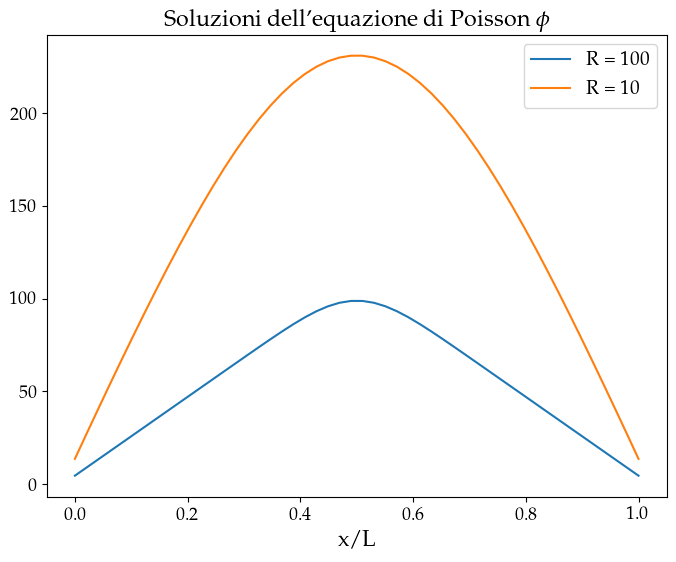

In [13]:
# Plot
fig, ax = plt.subplots()
ax.plot(x, phi1, label='R = 100')
ax.plot(x, phi2, label='R = 10')
ax.set_title(r"Soluzioni dell'equazione di Poisson $\phi$")
ax.set_xlabel(r'x/L')
ax.legend()
# ax.grid(alpha=0.4, ls='--')
plt.savefig('plots/poiss_sol.png', dpi=300)
plt.show()

## **LU decomposition**

In [14]:
def LU_dec(A_in):
    A = np.copy(A_in)
    n = np.shape(A)[0]
    L = np.eye(n)
    piv_sign = 1

    for j in range(n-1):
        # Find row with maximum absolute value in column j
        max_row = j + np.argmax(np.abs(A[j:, j]))
        if max_row != j:
            A[[j, max_row]] = A[[max_row, j]]
            if j > 0:
                L[[j, max_row], :j] = L[[max_row, j], :j]
            piv_sign *= -1


        # Gaussian elimination
        for i in range(j+1, n):
            c = A[i,j] / A[j,j]
            A[i,j:] -= c * A[j,j:]
            L[i, j] = c
    
    return L, A, piv_sign # A == U

L, U, piv_sign = LU_dec(A_test)
# print('L =\n', L)
# print()
# print('U =\n', U)
# print()
# print('A =\n', A_test)
# print()
# print('L@U =\n', (L@U))